# DeFi Sentinel - EDA & Feature Engineering
## Solana Rug Pull Detection - Data Analysis

Dataset: SolRPDS (116K+ liquidity pool records from 3.69B Solana transactions, 2021-2024)

**Goals:**
1. Understand the raw data distribution
2. Engineer features beyond the raw CSV (time-to-rug, liquidity velocity, drain asymmetry)
3. Visualize patterns that separate rug-pulls from legit tokens
4. Build a correlation matrix for feature selection
5. Prep for on-chain enrichment via Helius API

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('data/solrpds_dataset/CSV')

## 1. Load & Combine All Years

In [ ]:
import os
os.chdir(os.path.join(os.path.dirname(os.path.abspath('.')), ''))
# Ensure we're in project root regardless of notebook location
while not os.path.isfile('Architecture.md') and os.getcwd() != '/':
    os.chdir('..')

DATA_DIR = Path('data/raw/solrpds_dataset/CSV')
frames = []
for f in sorted(DATA_DIR.glob('*.csv')):
    tmp = pd.read_csv(f, low_memory=False)
    tmp['SOURCE_FILE'] = f.stem
    frames.append(tmp)
    print(f'{f.name}: {len(tmp):,} rows')

df = pd.concat(frames, ignore_index=True)
print(f'\nTotal: {len(df):,} rows, {len(df.columns)} columns')
print(f'Columns: {list(df.columns)}')

2021.csv: 1,703 rows
2022.csv: 3,695 rows
2023.csv: 15,477 rows
Jan_2024-Nov_2024.csv: 95,433 rows

Total: 116,308 rows, 13 columns
Columns: ['LIQUIDITY_POOL_ADDRESS', 'MINT', 'TOTAL_ADDED_LIQUIDITY', 'TOTAL_REMOVED_LIQUIDITY', 'NUM_LIQUIDITY_ADDS', 'NUM_LIQUIDITY_REMOVES', 'ADD_TO_REMOVE_RATIO', 'LAST_POOL_ACTIVITY_TIMESTAMP', 'FIRST_POOL_ACTIVITY_TIMESTAMP', 'LAST_SWAP_TIMESTAMP', 'LAST_SWAP_TX_ID', 'INACTIVITY_STATUS', 'SOURCE_FILE']


In [3]:
# Basic info
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Unique mints: {df["MINT"].nunique():,}')
print(f'=== Unique pools: {df["LIQUIDITY_POOL_ADDRESS"].nunique():,}')
print(f'\n=== Target Distribution ===')
print(df['INACTIVITY_STATUS'].value_counts())
print(f'\nInactive (rug-pull) rate: {(df["INACTIVITY_STATUS"] == "Inactive").mean()*100:.2f}%')

=== Data Types ===
LIQUIDITY_POOL_ADDRESS            object
MINT                              object
TOTAL_ADDED_LIQUIDITY            float64
TOTAL_REMOVED_LIQUIDITY          float64
NUM_LIQUIDITY_ADDS               float64
NUM_LIQUIDITY_REMOVES            float64
ADD_TO_REMOVE_RATIO              float64
LAST_POOL_ACTIVITY_TIMESTAMP      object
FIRST_POOL_ACTIVITY_TIMESTAMP     object
LAST_SWAP_TIMESTAMP               object
LAST_SWAP_TX_ID                   object
INACTIVITY_STATUS                 object
SOURCE_FILE                       object
dtype: object

=== Unique mints: 33,358
=== Unique pools: 63,521

=== Target Distribution ===
INACTIVITY_STATUS
Active      93749
Inactive    22555
Name: count, dtype: int64

Inactive (rug-pull) rate: 19.39%


In [4]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_df[missing_df.missing_count > 0])
if missing_df.missing_count.sum() == 0:
    print('No missing values.')

print(f'\n=== Numeric Summary ===')
df.describe()

                               missing_count  missing_pct
MINT                                       4         0.00
TOTAL_ADDED_LIQUIDITY                      4         0.00
TOTAL_REMOVED_LIQUIDITY                    4         0.00
NUM_LIQUIDITY_ADDS                         4         0.00
NUM_LIQUIDITY_REMOVES                      4         0.00
ADD_TO_REMOVE_RATIO                        4         0.00
LAST_POOL_ACTIVITY_TIMESTAMP               4         0.00
FIRST_POOL_ACTIVITY_TIMESTAMP              4         0.00
LAST_SWAP_TIMESTAMP                      623         0.54
LAST_SWAP_TX_ID                          623         0.54
INACTIVITY_STATUS                          4         0.00

=== Numeric Summary ===


,TOTAL_ADDED_LIQUIDITY,TOTAL_REMOVED_LIQUIDITY,NUM_LIQUIDITY_ADDS,NUM_LIQUIDITY_REMOVES,ADD_TO_REMOVE_RATIO
count,1.163040e+05,1.163040e+05,1.163040e+05,1.163040e+05,1.163040e+05
mean,4.701548e+13,1.464441e+14,1.400667e+03,9.684045e+02,6.613697e+04
std,1.023856e+16,2.178581e+16,6.820402e+04,6.744009e+04,8.720293e+06
min,1.000000e-09,1.000000e+00,1.000000e+00,1.000000e+00,1.800672e-17
25%,5.702012e+01,1.135878e+02,2.000000e+00,2.000000e+00,4.482402e-01
50%,5.928520e+04,9.400434e+04,6.000000e+00,4.000000e+00,9.140659e-01
75%,4.420064e+06,9.055780e+06,2.000000e+01,1.600000e+01,1.134797e+00
max,3.451333e+18,5.568529e+18,1.178061e+07,1.179543e+07,1.988868e+09


## 2. Feature Engineering
Build features a quant would care about -- beyond the raw CSV.

In [5]:
# Parse timestamps
for col in ['FIRST_POOL_ACTIVITY_TIMESTAMP', 'LAST_POOL_ACTIVITY_TIMESTAMP', 'LAST_SWAP_TIMESTAMP']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Binary target
df['IS_RUG'] = (df['INACTIVITY_STATUS'] == 'Inactive').astype(int)

# --- TIME-TO-RUG (lifespan): how long did the pool survive? ---
df['LIFESPAN_HOURS'] = (df['LAST_POOL_ACTIVITY_TIMESTAMP'] - df['FIRST_POOL_ACTIVITY_TIMESTAMP']).dt.total_seconds() / 3600
df['LIFESPAN_DAYS'] = df['LIFESPAN_HOURS'] / 24

# --- LIQUIDITY VELOCITY: how aggressively they drained ---
# total_removed / active_time (SOL per hour drained)
df['DRAIN_VELOCITY'] = df['TOTAL_REMOVED_LIQUIDITY'] / df['LIFESPAN_HOURS'].replace(0, np.nan)

# --- NET LIQUIDITY ---
df['LIQUIDITY_NET'] = df['TOTAL_ADDED_LIQUIDITY'] - df['TOTAL_REMOVED_LIQUIDITY']

# --- REMOVED RATIO (what fraction of added was removed) ---
df['REMOVED_RATIO'] = df['TOTAL_REMOVED_LIQUIDITY'] / df['TOTAL_ADDED_LIQUIDITY'].replace(0, np.nan)

# --- REMOVE/ADD ASYMMETRY ---
# Few large removes vs many small adds = classic rug pattern
df['AVG_ADD_SIZE'] = df['TOTAL_ADDED_LIQUIDITY'] / df['NUM_LIQUIDITY_ADDS'].replace(0, np.nan)
df['AVG_REMOVE_SIZE'] = df['TOTAL_REMOVED_LIQUIDITY'] / df['NUM_LIQUIDITY_REMOVES'].replace(0, np.nan)
df['REMOVE_ADD_SIZE_RATIO'] = df['AVG_REMOVE_SIZE'] / df['AVG_ADD_SIZE'].replace(0, np.nan)

# --- ADD/REMOVE FREQUENCY ---
# removes per hour of activity
df['REMOVE_FREQUENCY'] = df['NUM_LIQUIDITY_REMOVES'] / df['LIFESPAN_HOURS'].replace(0, np.nan)
df['ADD_FREQUENCY'] = df['NUM_LIQUIDITY_ADDS'] / df['LIFESPAN_HOURS'].replace(0, np.nan)

# --- SWAP DELAY: time between last pool activity and last swap ---
df['SWAP_DELAY_HOURS'] = (df['LAST_SWAP_TIMESTAMP'] - df['LAST_POOL_ACTIVITY_TIMESTAMP']).dt.total_seconds() / 3600

# --- LOG TRANSFORMS (for skewed distributions) ---
df['LOG_ADDED'] = np.log1p(df['TOTAL_ADDED_LIQUIDITY'].clip(lower=0))
df['LOG_REMOVED'] = np.log1p(df['TOTAL_REMOVED_LIQUIDITY'].clip(lower=0))

# --- YEAR for temporal analysis ---
df['YEAR'] = df['FIRST_POOL_ACTIVITY_TIMESTAMP'].dt.year

print(f'Engineered {len(df.columns)} total columns')
print(f'New features: LIFESPAN_HOURS, LIFESPAN_DAYS, DRAIN_VELOCITY, LIQUIDITY_NET,')
print(f'  REMOVED_RATIO, AVG_ADD_SIZE, AVG_REMOVE_SIZE, REMOVE_ADD_SIZE_RATIO,')
print(f'  REMOVE_FREQUENCY, ADD_FREQUENCY, SWAP_DELAY_HOURS, LOG_ADDED, LOG_REMOVED')

Engineered 28 total columns
New features: LIFESPAN_HOURS, LIFESPAN_DAYS, DRAIN_VELOCITY, LIQUIDITY_NET,
  REMOVED_RATIO, AVG_ADD_SIZE, AVG_REMOVE_SIZE, REMOVE_ADD_SIZE_RATIO,
  REMOVE_FREQUENCY, ADD_FREQUENCY, SWAP_DELAY_HOURS, LOG_ADDED, LOG_REMOVED


## 3. Rug-Pull Lifespan Distribution
The SolRPDS paper found 60% of rugs last < 1 day. Let's verify and visualize.

Rug pulls: 22,555
Legit pools: 93,753

--- Rug-Pull Lifespan Stats ---
count    22555.000000
mean       532.306952
std       1300.148187
min          0.001111
25%          0.641389
50%         15.956389
75%        241.865556
max       8569.311389
Name: LIFESPAN_HOURS, dtype: float64

% of rugs lasting < 24 hours: 54.6%
% of rugs lasting < 1 hour:   29.5%
% of rugs lasting < 7 days:   71.6%


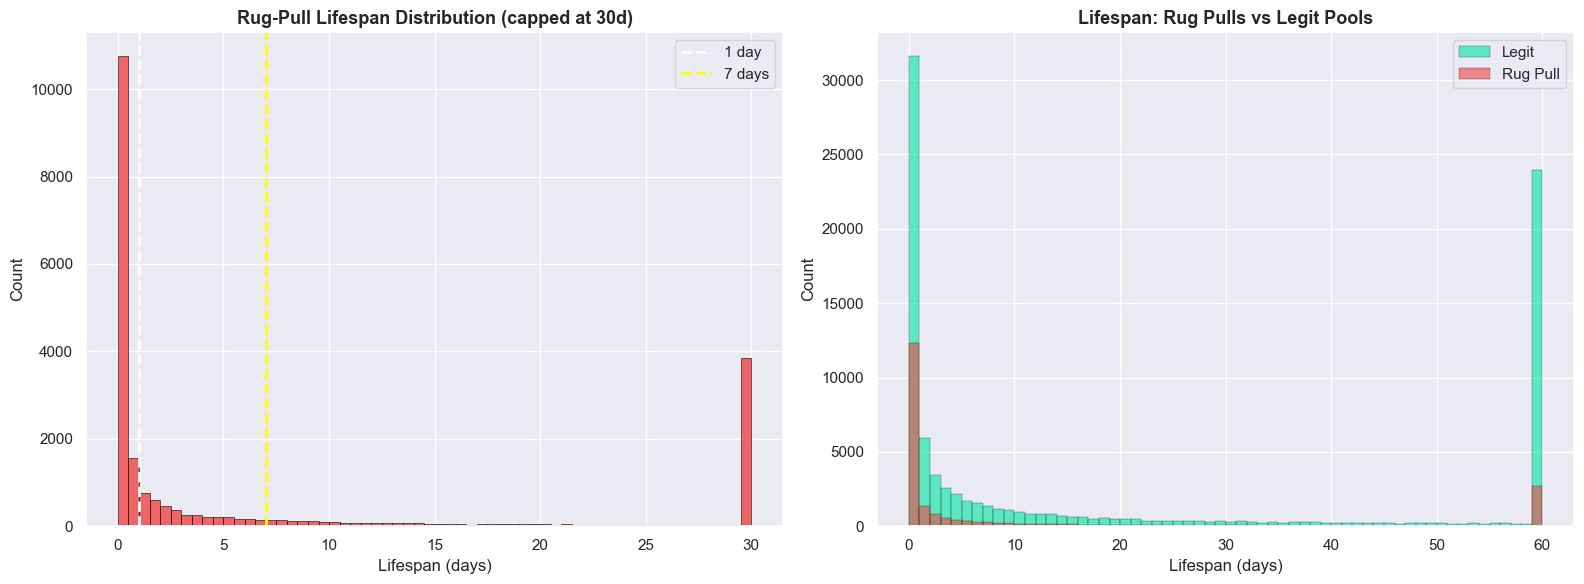

In [ ]:
rugs = df[df['IS_RUG'] == 1].copy()
legit = df[df['IS_RUG'] == 0].copy()

print(f'Rug pulls: {len(rugs):,}')
print(f'Legit pools: {len(legit):,}')
print(f'\n--- Rug-Pull Lifespan Stats ---')
print(rugs['LIFESPAN_HOURS'].describe())
print(f'\n% of rugs lasting < 24 hours: {(rugs["LIFESPAN_HOURS"] < 24).mean()*100:.1f}%')
print(f'% of rugs lasting < 1 hour:   {(rugs["LIFESPAN_HOURS"] < 1).mean()*100:.1f}%')
print(f'% of rugs lasting < 7 days:   {(rugs["LIFESPAN_DAYS"] < 7).mean()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: histogram of rug lifespan (capped at 30 days for visibility)
axes[0].hist(rugs['LIFESPAN_DAYS'].clip(upper=30).dropna(), bins=60, color='#ef4444', alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0].axvline(x=1, color='white', linestyle='--', linewidth=2, label='1 day')
axes[0].axvline(x=7, color='yellow', linestyle='--', linewidth=2, label='7 days')
axes[0].set_xlabel('Lifespan (days)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Rug-Pull Lifespan Distribution (capped at 30d)', fontsize=13, fontweight='bold')
axes[0].legend()

# Right: comparison rug vs legit
axes[1].hist(legit['LIFESPAN_DAYS'].clip(upper=60).dropna(), bins=60, alpha=0.6, label='Legit', color='#00e5a0', edgecolor='black', linewidth=0.3)
axes[1].hist(rugs['LIFESPAN_DAYS'].clip(upper=60).dropna(), bins=60, alpha=0.6, label='Rug Pull', color='#ef4444', edgecolor='black', linewidth=0.3)
axes[1].set_xlabel('Lifespan (days)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Lifespan: Rug Pulls vs Legit Pools', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/figures/eda_lifespan_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Add-to-Remove Ratio vs Time-to-Rug
Do fast rugs have distinctive liquidity patterns?

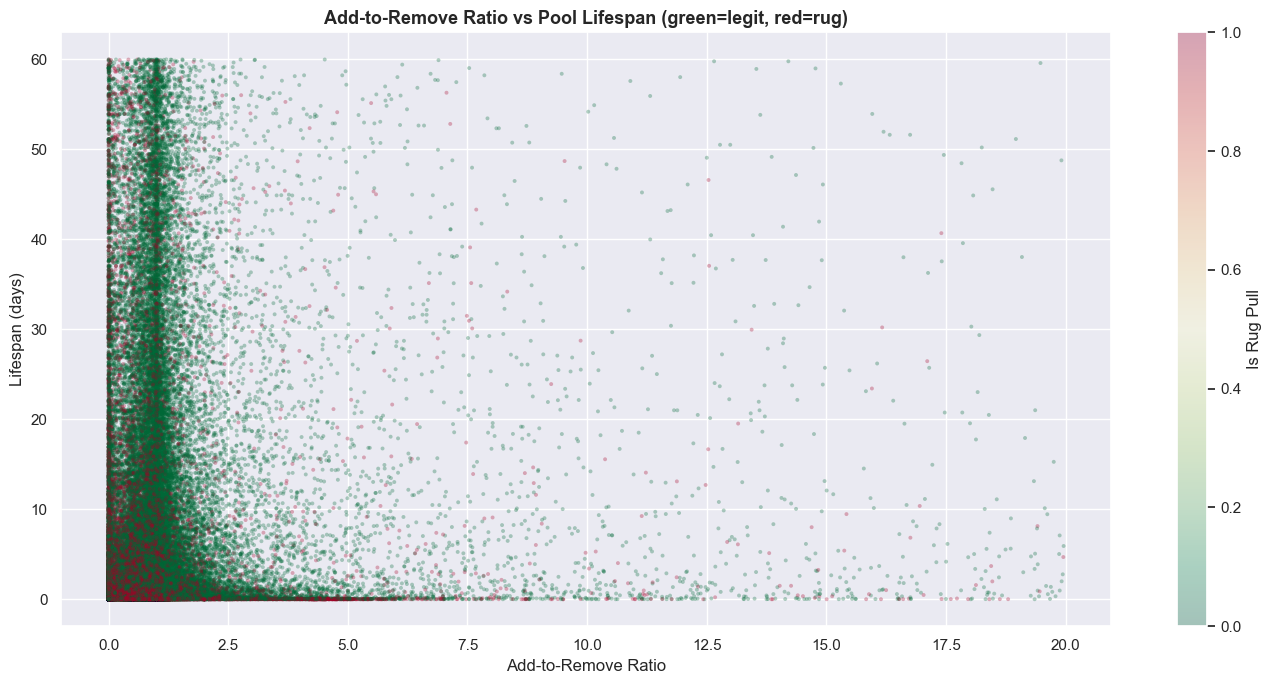

In [ ]:
# Scatter: add_to_remove_ratio vs lifespan, colored by label
plot_df = df[df['LIFESPAN_DAYS'].notna() & df['ADD_TO_REMOVE_RATIO'].notna()].copy()
plot_df = plot_df[plot_df['LIFESPAN_DAYS'] < 60]  # clip outliers
plot_df = plot_df[plot_df['ADD_TO_REMOVE_RATIO'] < 20]  # clip extreme ratios

fig, ax = plt.subplots(figsize=(14, 7))
scatter = ax.scatter(
    plot_df['ADD_TO_REMOVE_RATIO'],
    plot_df['LIFESPAN_DAYS'],
    c=plot_df['IS_RUG'],
    cmap='RdYlGn_r',
    alpha=0.3,
    s=8,
    edgecolors='none'
)
ax.set_xlabel('Add-to-Remove Ratio', fontsize=12)
ax.set_ylabel('Lifespan (days)', fontsize=12)
ax.set_title('Add-to-Remove Ratio vs Pool Lifespan (green=legit, red=rug)', fontsize=13, fontweight='bold')
plt.colorbar(scatter, label='Is Rug Pull')
plt.tight_layout()
plt.savefig('data/figures/eda_ratio_vs_lifespan.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Drain Velocity & Remove/Add Asymmetry

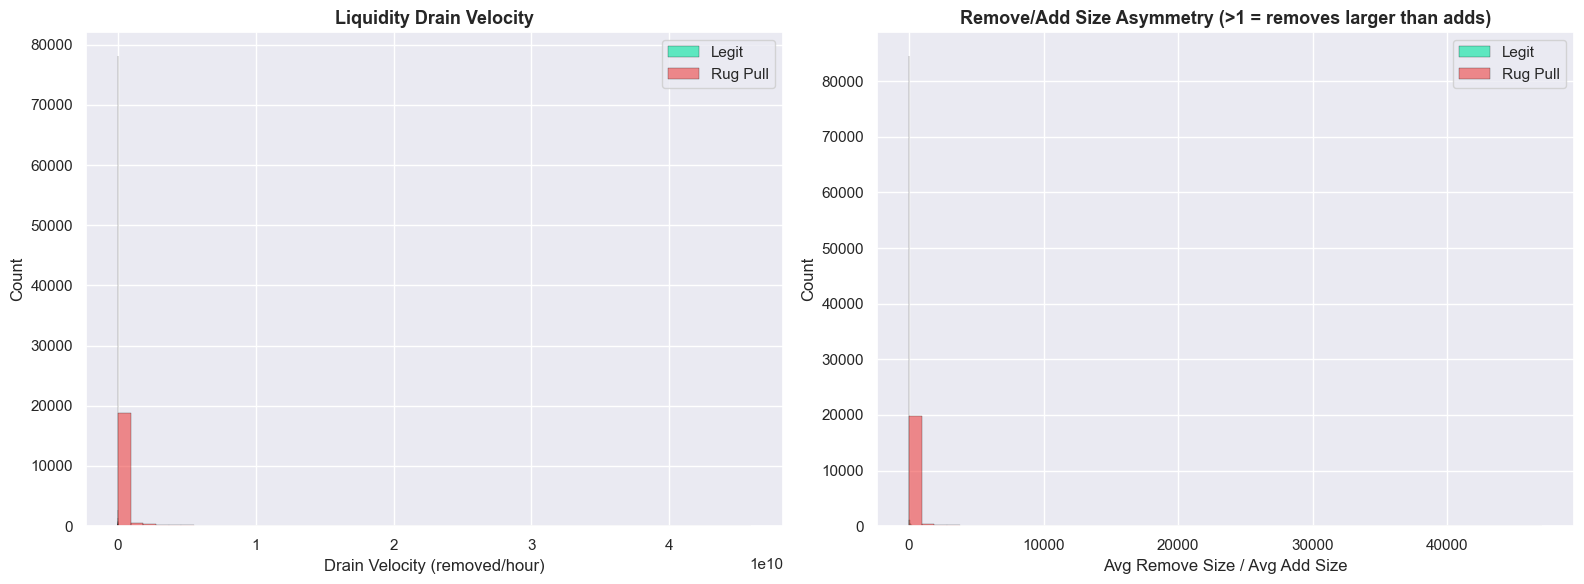

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Drain velocity comparison
for label, color, name in [(0, '#00e5a0', 'Legit'), (1, '#ef4444', 'Rug Pull')]:
    subset = df[(df['IS_RUG'] == label) & df['DRAIN_VELOCITY'].notna()]
    subset = subset[subset['DRAIN_VELOCITY'] < subset['DRAIN_VELOCITY'].quantile(0.95)]
    axes[0].hist(subset['DRAIN_VELOCITY'], bins=50, alpha=0.6, color=color, label=name, edgecolor='black', linewidth=0.3)

axes[0].set_xlabel('Drain Velocity (removed/hour)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Liquidity Drain Velocity', fontsize=13, fontweight='bold')
axes[0].legend()

# Remove/Add size asymmetry
for label, color, name in [(0, '#00e5a0', 'Legit'), (1, '#ef4444', 'Rug Pull')]:
    subset = df[(df['IS_RUG'] == label) & df['REMOVE_ADD_SIZE_RATIO'].notna()]
    subset = subset[subset['REMOVE_ADD_SIZE_RATIO'] < subset['REMOVE_ADD_SIZE_RATIO'].quantile(0.95)]
    axes[1].hist(subset['REMOVE_ADD_SIZE_RATIO'], bins=50, alpha=0.6, color=color, label=name, edgecolor='black', linewidth=0.3)

axes[1].set_xlabel('Avg Remove Size / Avg Add Size', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Remove/Add Size Asymmetry (>1 = removes larger than adds)', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/figures/eda_drain_asymmetry.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Temporal Patterns: Rug Pulls by Year

  YEAR  total  rugs  rug_pct  legit
2021.0   1702    90     5.29   1612
2022.0   3694   495    13.40   3199
2023.0  15476  2896    18.71  12580
2024.0  95432 19074    19.99  76358


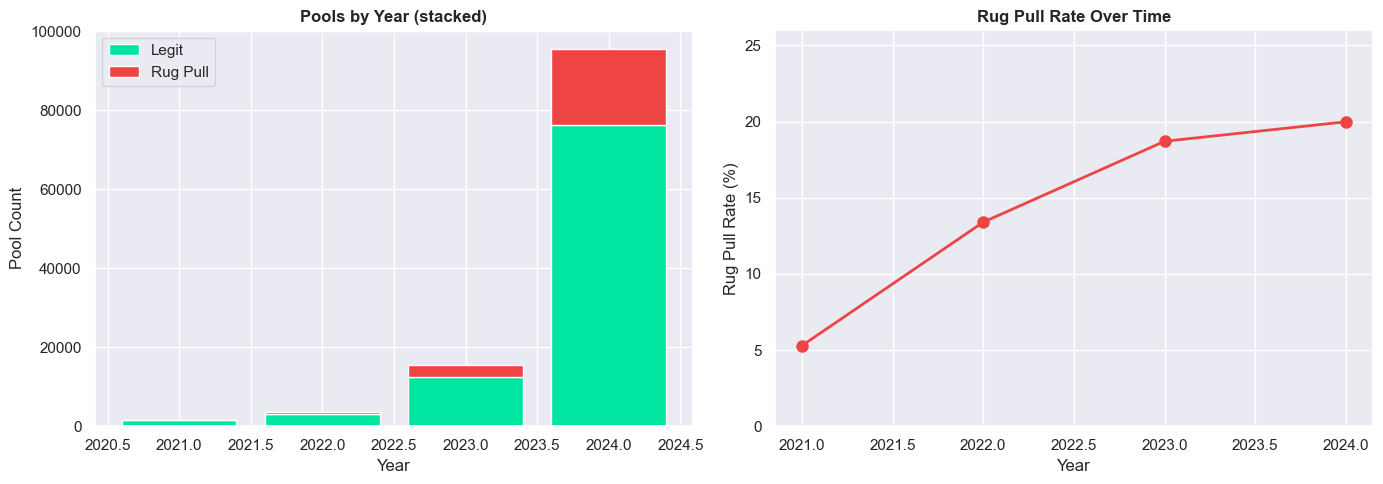

In [ ]:
yearly = df.groupby('YEAR').agg(
    total=('IS_RUG', 'count'),
    rugs=('IS_RUG', 'sum'),
).reset_index()
yearly['rug_pct'] = (yearly['rugs'] / yearly['total'] * 100).round(2)
yearly['legit'] = yearly['total'] - yearly['rugs']
print(yearly.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar: total pools per year stacked by rug/legit
axes[0].bar(yearly['YEAR'], yearly['legit'], label='Legit', color='#00e5a0')
axes[0].bar(yearly['YEAR'], yearly['rugs'], bottom=yearly['legit'], label='Rug Pull', color='#ef4444')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Pool Count')
axes[0].set_title('Pools by Year (stacked)', fontweight='bold')
axes[0].legend()

# Line: rug rate over time
axes[1].plot(yearly['YEAR'], yearly['rug_pct'], 'o-', color='#ef4444', linewidth=2, markersize=8)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Rug Pull Rate (%)')
axes[1].set_title('Rug Pull Rate Over Time', fontweight='bold')
axes[1].set_ylim(0, yearly['rug_pct'].max() * 1.3)

plt.tight_layout()
plt.savefig('data/figures/eda_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Removed Ratio Distribution (fraction of liquidity drained)

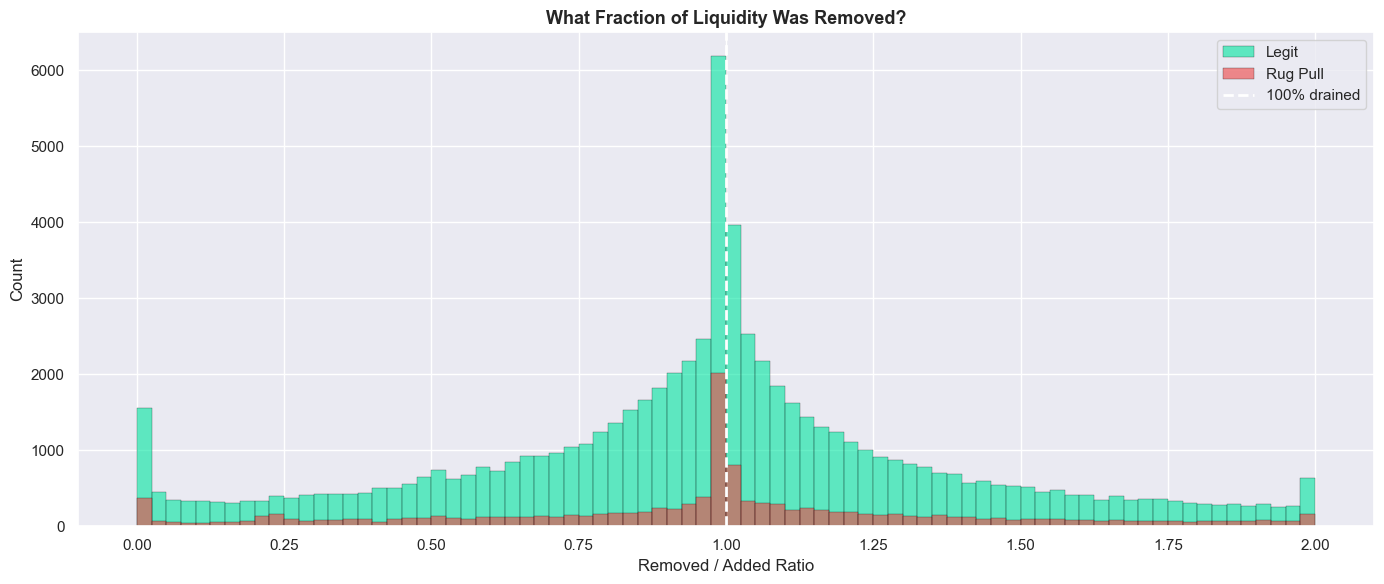

Rugs with removed_ratio >= 0.95 (drained 95%+): 78.7%
Legit with removed_ratio >= 0.95: 67.4%


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

for label, color, name in [(0, '#00e5a0', 'Legit'), (1, '#ef4444', 'Rug Pull')]:
    subset = df[(df['IS_RUG'] == label) & df['REMOVED_RATIO'].notna()]
    subset = subset[subset['REMOVED_RATIO'] <= 2.0]  # clip for viz
    ax.hist(subset['REMOVED_RATIO'], bins=80, alpha=0.6, color=color, label=name, edgecolor='black', linewidth=0.3)

ax.axvline(x=1.0, color='white', linestyle='--', linewidth=2, label='100% drained')
ax.set_xlabel('Removed / Added Ratio', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('What Fraction of Liquidity Was Removed?', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('data/figures/eda_removed_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Rugs with removed_ratio >= 0.95 (drained 95%+): {(rugs["REMOVED_RATIO"] >= 0.95).mean()*100:.1f}%')
print(f'Legit with removed_ratio >= 0.95: {(legit["REMOVED_RATIO"] >= 0.95).mean()*100:.1f}%')

## 8. Correlation Matrix
All engineered features -- what's correlated, what's redundant, what separates rug from legit.

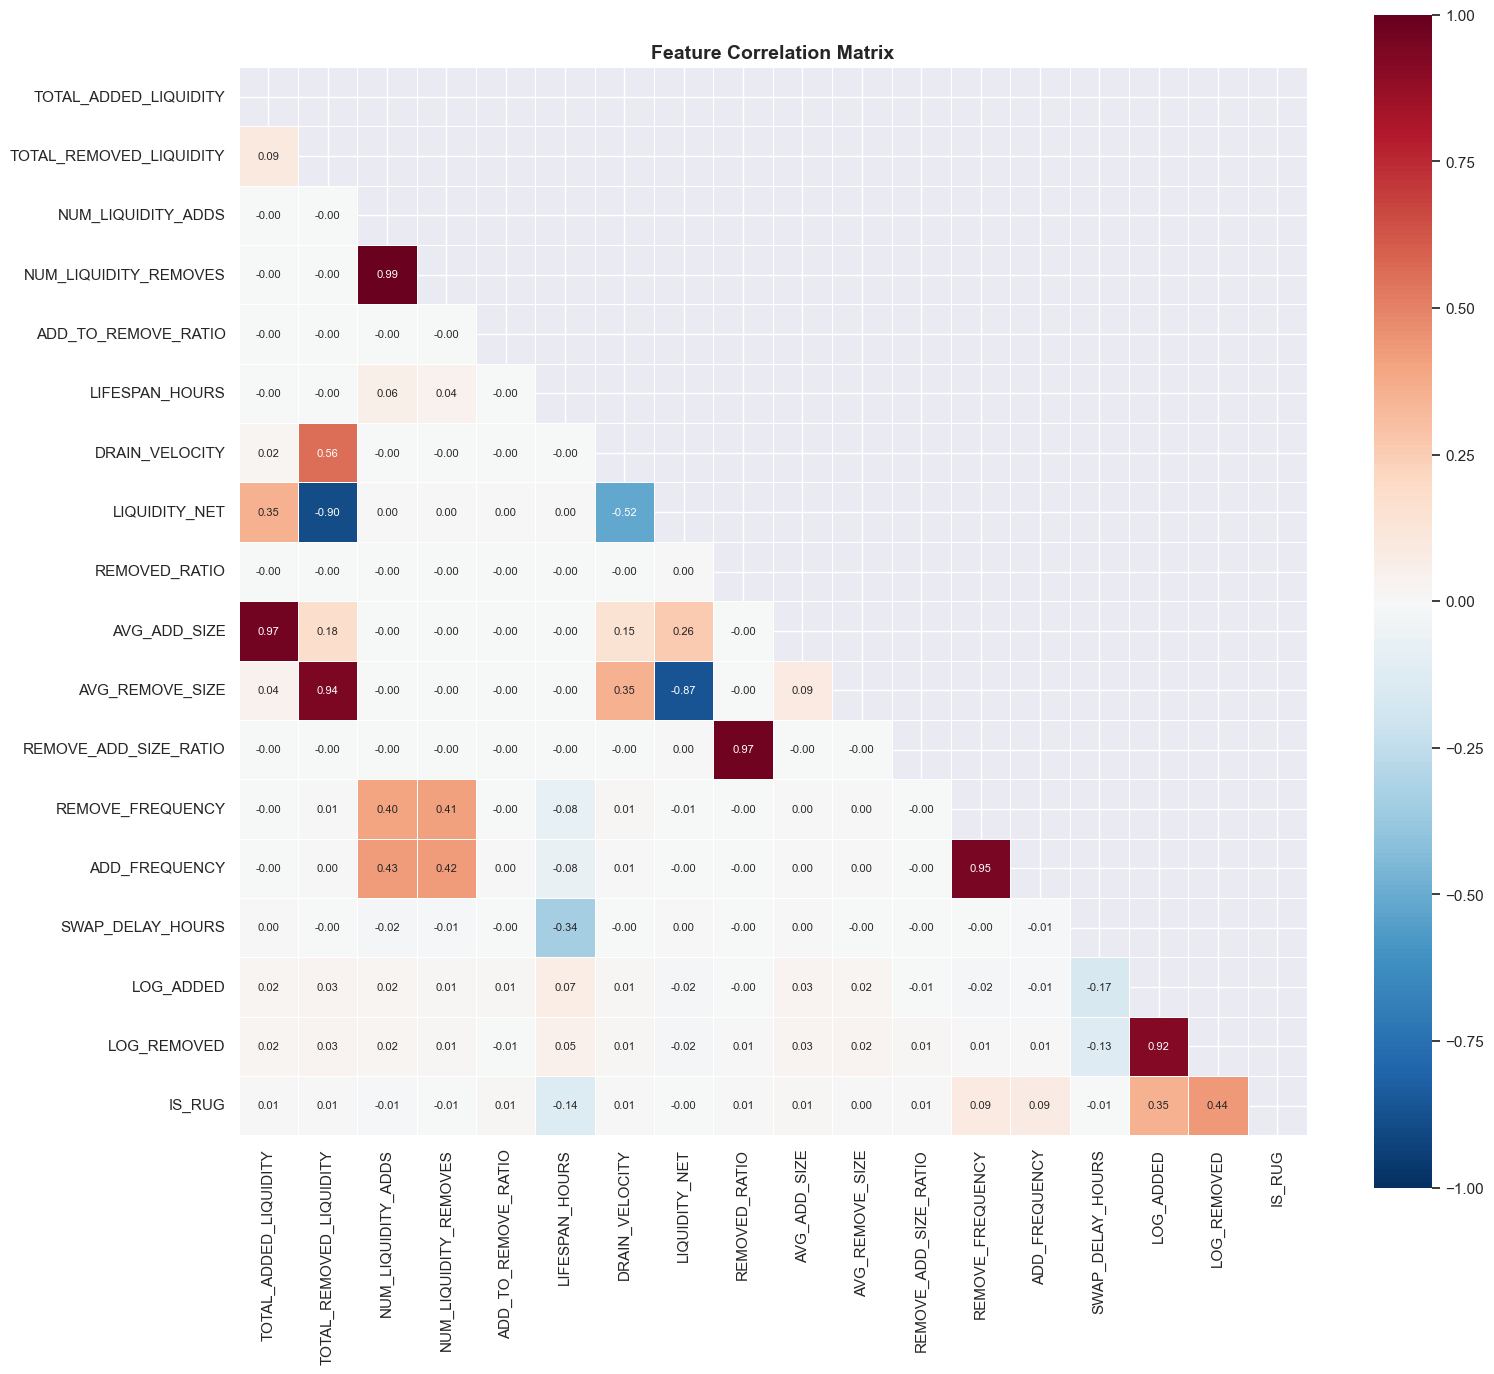


=== Correlation with IS_RUG (target) ===
  + LOG_REMOVED                    +0.4368
  + LOG_ADDED                      +0.3526
  - LIFESPAN_HOURS                 -0.1406
  + REMOVE_FREQUENCY               +0.0912
  + ADD_FREQUENCY                  +0.0855
  + ADD_TO_REMOVE_RATIO            +0.0120
  + AVG_ADD_SIZE                   +0.0114
  - NUM_LIQUIDITY_ADDS             -0.0099
  + TOTAL_ADDED_LIQUIDITY          +0.0077
  + REMOVE_ADD_SIZE_RATIO          +0.0076
  + TOTAL_REMOVED_LIQUIDITY        +0.0071
  - NUM_LIQUIDITY_REMOVES          -0.0069
  - SWAP_DELAY_HOURS               -0.0065
  + REMOVED_RATIO                  +0.0064
  + DRAIN_VELOCITY                 +0.0062
  + AVG_REMOVE_SIZE                +0.0034
  - LIQUIDITY_NET                  -0.0033


In [ ]:
feature_cols = [
    'TOTAL_ADDED_LIQUIDITY', 'TOTAL_REMOVED_LIQUIDITY',
    'NUM_LIQUIDITY_ADDS', 'NUM_LIQUIDITY_REMOVES', 'ADD_TO_REMOVE_RATIO',
    'LIFESPAN_HOURS', 'DRAIN_VELOCITY', 'LIQUIDITY_NET', 'REMOVED_RATIO',
    'AVG_ADD_SIZE', 'AVG_REMOVE_SIZE', 'REMOVE_ADD_SIZE_RATIO',
    'REMOVE_FREQUENCY', 'ADD_FREQUENCY', 'SWAP_DELAY_HOURS',
    'LOG_ADDED', 'LOG_REMOVED', 'IS_RUG'
]

corr_df = df[feature_cols].replace([np.inf, -np.inf], np.nan).dropna()
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
    annot_kws={'size': 8}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/figures/eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Show correlations with target
print('\n=== Correlation with IS_RUG (target) ===')
target_corr = corr['IS_RUG'].drop('IS_RUG').sort_values(key=abs, ascending=False)
for feat, val in target_corr.items():
    direction = '+' if val > 0 else '-'
    print(f'  {direction} {feat:30s} {val:+.4f}')

## 9. Key Separating Features (Box Plots)

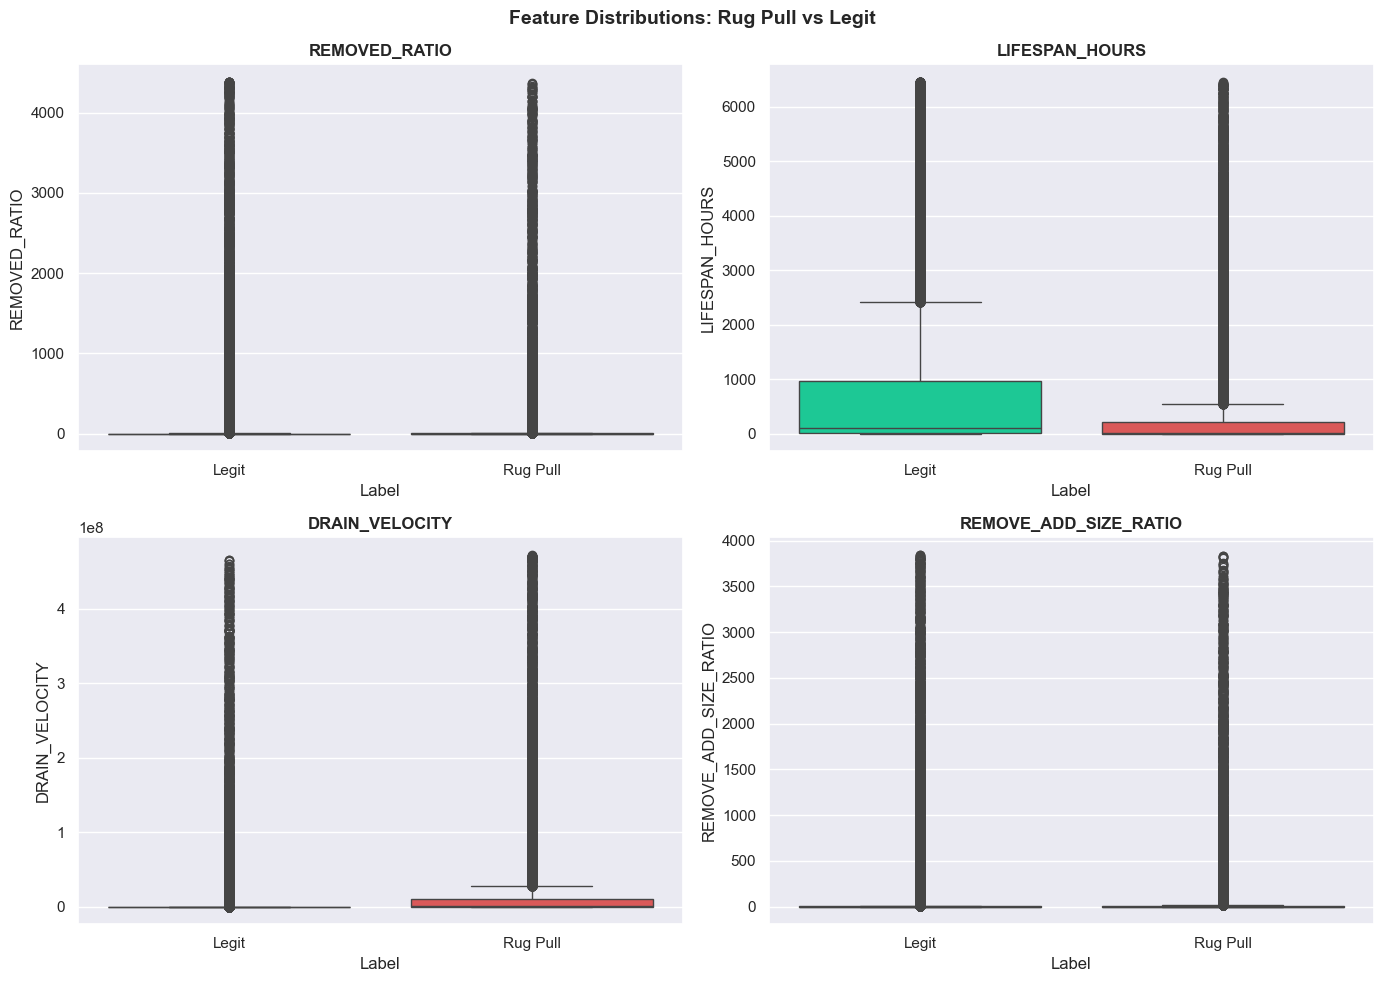

In [ ]:
# Top features that separate rug from legit -- box plot comparison
top_features = ['REMOVED_RATIO', 'LIFESPAN_HOURS', 'DRAIN_VELOCITY', 'REMOVE_ADD_SIZE_RATIO']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feat in enumerate(top_features):
    ax = axes[idx // 2][idx % 2]
    plot_data = df[[feat, 'IS_RUG']].replace([np.inf, -np.inf], np.nan).dropna()
    # Clip at 95th percentile for visibility
    cap = plot_data[feat].quantile(0.95)
    plot_data = plot_data[plot_data[feat] <= cap]
    
    plot_data['Label'] = plot_data['IS_RUG'].map({0: 'Legit', 1: 'Rug Pull'})
    sns.boxplot(data=plot_data, x='Label', y=feat, ax=ax,
                palette={'Legit': '#00e5a0', 'Rug Pull': '#ef4444'})
    ax.set_title(feat, fontweight='bold')

plt.suptitle('Feature Distributions: Rug Pull vs Legit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/figures/eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Dataset Summary & Next Steps

Summary of what we have from the raw CSV alone, and what Helius on-chain enrichment will add.

In [13]:
print('=' * 70)
print('DATASET SUMMARY')
print('=' * 70)
print(f'Total records:      {len(df):>10,}')
print(f'Unique mints:       {df["MINT"].nunique():>10,}')
print(f'Unique pools:       {df["LIQUIDITY_POOL_ADDRESS"].nunique():>10,}')
print(f'Rug pulls:          {len(rugs):>10,} ({len(rugs)/len(df)*100:.1f}%)')
print(f'Legit pools:        {len(legit):>10,} ({len(legit)/len(df)*100:.1f}%)')
print(f'\nFeatures from CSV:  12 raw columns')
print(f'Engineered features: 13 new columns')
print(f'Total features:     {len(df.columns)} columns')
print('=' * 70)
print()
print('FEATURES FROM CSV (what we have):')
print('  - Liquidity adds/removes (amounts + counts + ratio)')
print('  - Pool activity timestamps')
print('  - Inactivity label (our target)')
print()
print('ENGINEERED FROM CSV (what we built above):')
print('  - Lifespan (hours/days)')
print('  - Drain velocity (removed per hour)')
print('  - Net liquidity')
print('  - Removed ratio')
print('  - Remove/Add size asymmetry')
print('  - Add/Remove frequency')
print('  - Swap delay')
print('  - Log-transformed amounts')
print()
print('WILL ADD VIA HELIUS API (on-chain enrichment):')
print('  - Mint authority retained (bool)')
print('  - Freeze authority retained (bool)')
print('  - Holder concentration (top1/5/10/20 %)')
print('  - Token metadata presence (name, image, URI)')
print('  - Token program (SPL vs Token-2022)')
print('  - Is mutable / is burnt')
print('  - Deployer wallet age (from first tx timestamp)')
print('  - Token price at time of query')

DATASET SUMMARY
Total records:         116,308
Unique mints:           33,358
Unique pools:           63,521
Rug pulls:              22,555 (19.4%)
Legit pools:            93,753 (80.6%)

Features from CSV:  12 raw columns
Engineered features: 13 new columns
Total features:     28 columns

FEATURES FROM CSV (what we have):
  - Liquidity adds/removes (amounts + counts + ratio)
  - Pool activity timestamps
  - Inactivity label (our target)

ENGINEERED FROM CSV (what we built above):
  - Lifespan (hours/days)
  - Drain velocity (removed per hour)
  - Net liquidity
  - Removed ratio
  - Remove/Add size asymmetry
  - Add/Remove frequency
  - Swap delay
  - Log-transformed amounts

WILL ADD VIA HELIUS API (on-chain enrichment):
  - Mint authority retained (bool)
  - Freeze authority retained (bool)
  - Holder concentration (top1/5/10/20 %)
  - Token metadata presence (name, image, URI)
  - Token program (SPL vs Token-2022)
  - Is mutable / is burnt
  - Deployer wallet age (from first tx time